<a href="https://colab.research.google.com/github/you444Mo/Python-Projects/blob/main/GEN_BUS_657_Assignment_7_Spam_Detection_Moreimi_Zachary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Spam Classification

Obj:

Build a spam classifier using text processing and suitable Machine Learning Models.


* Load the dataset. It is available in the GitHub repositoryLinks to an external site. or here as a csv to download Download here as a csv to download.
* The dataset consists of messages (v2) that are either classified as spam or ham (i.e., not spam)---in v1.
* Build a classifier (note that this is a binary classification problem!). In doing so:
  * Process the text in the messages so that it is usable by a ML algorithm (possibly a logistic regression model or a simple neural net as here or possibly by an RNN as here).
  * Split the data into a training (70%) and a test (30%) dataset.
  * Train your ML based on the training data and evaluate the performance based on the test data.

### Import Libraries and Data

In [1]:
### Import Needed Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string

### Text classificatioon packages
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalMaxPooling1D

In [2]:
### Clone Class Git Repo
!git clone https://github.com/danielbauer1979/MSDIA_PredictiveModelingAndMachineLearning.git

Cloning into 'MSDIA_PredictiveModelingAndMachineLearning'...
remote: Enumerating objects: 367, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 367 (delta 71), reused 15 (delta 15), pack-reused 253 (from 2)
Receiving objects: 100% (367/367), 49.94 MiB | 8.28 MiB/s, done.
Resolving deltas: 100% (182/182), done.
Updating files: 100% (82/82), done.


In [3]:
### Read Data Into DF
Spam_DF = pd.read_csv(
    '/content/MSDIA_PredictiveModelingAndMachineLearning/GB888_VII_10_Spam.csv',
    encoding="ISO-8859-1"
    )

In [4]:
### View Data
Spam_DF.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### Data Cleansing + EDA

In [5]:
### View Shape of Data
Spam_DF.shape

(5572, 5)

In [6]:
### View Null Records
Spam_DF.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


Will Remove Unamed Columns

#### Cleansing:

In [7]:
### Create Copy of Spam_DF
Spam_DF_Cleaned = Spam_DF.copy()
### Remove uneeded columns from copy
Spam_DF_Cleaned = Spam_DF_Cleaned.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'])
### Rename Columns
Spam_DF_Cleaned = Spam_DF_Cleaned.rename(
    columns = {
        'v1' : 'Spam_Flag',
        'v2' : 'Message'
    }
  )
### Re-Classify Spam_Flag Field
Spam_DF_Cleaned['Spam_Flag'] = np.where(Spam_DF_Cleaned['Spam_Flag'] == 'ham','not spam','spam')

### Convert Spam_Flag Field to Dummy Variable
Spam_DF_Cleaned['Spam_Flag'] = np.where(Spam_DF_Cleaned['Spam_Flag'] == 'spam', 1, 0)

### Convert Spam_Flag Field to Categorical Variable
Spam_DF_Cleaned['Spam_Flag'] = pd.Categorical(Spam_DF_Cleaned['Spam_Flag'])

### View Cleaned DF
print(Spam_DF_Cleaned.info())
print()
print(Spam_DF_Cleaned.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Spam_Flag  5572 non-null   category
 1   Message    5572 non-null   object  
dtypes: category(1), object(1)
memory usage: 49.2+ KB
None

  Spam_Flag                                            Message
0         0  Go until jurong point, crazy.. Available only ...
1         0                      Ok lar... Joking wif u oni...
2         1  Free entry in 2 a wkly comp to win FA Cup fina...
3         0  U dun say so early hor... U c already then say...
4         0  Nah I don't think he goes to usf, he lives aro...


In [8]:
### Remove Punctuation in Message Field
def remove_punctuation(text):
  translator = str.maketrans('', '', string.punctuation)
  return text.translate(translator)

Spam_DF_Cleaned['Message'] = Spam_DF_Cleaned['Message'].apply(remove_punctuation)
Spam_DF_Cleaned.head()

,Spam_Flag,Message
0,0,Go until jurong point crazy Available only in ...
1,0,Ok lar Joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor U c already then say
4,0,Nah I dont think he goes to usf he lives aroun...


In [9]:
### Make all text in message lower case
Spam_DF_Cleaned['Message'] = Spam_DF_Cleaned['Message'].str.lower()
Spam_DF_Cleaned.head()

,Spam_Flag,Message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


In [10]:
### Remove Stopwords
nltk.download('stopwords')
stop = stopwords.words('english')
Spam_DF_Cleaned['Message'] = Spam_DF_Cleaned['Message'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)])) ### removes all non-important words
Spam_DF_Cleaned['Message'].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Message
0,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni
2,free entry 2 wkly comp win fa cup final tkts 2...
3,u dun say early hor u c already say
4,nah dont think goes usf lives around though


In [11]:
### Perform Stemming (ie: Remove ly or ing endings)
porter = PorterStemmer()
Spam_DF_Cleaned['Message'] = Spam_DF_Cleaned['Message'].apply(lambda x: ' '.join([porter.stem(word) for word in x.split()]))
Spam_DF_Cleaned.head()

,Spam_Flag,Message
0,0,go jurong point crazi avail bugi n great world...
1,0,ok lar joke wif u oni
2,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say earli hor u c alreadi say
4,0,nah dont think goe usf live around though


In [12]:
### Perform Lemmatization
nltk.download('wordnet') ### takes combined words and converts it to the root word
lemmatizer = WordNetLemmatizer()
Spam_DF_Cleaned['Message'] = Spam_DF_Cleaned['Message'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
Spam_DF_Cleaned.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,Spam_Flag,Message
0,0,go jurong point crazi avail bugi n great world...
1,0,ok lar joke wif u oni
2,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say earli hor u c alreadi say
4,0,nah dont think goe usf live around though


#### EDA:

In [13]:
### Check for nulls in clean df
Spam_DF_Cleaned.isnull().sum()

,0
Spam_Flag,0
Message,0


In [14]:
### Check for Dupes
Spam_DF_Cleaned[Spam_DF_Cleaned.duplicated()]

,Spam_Flag,Message
102,0,per request mell mell oru minnaminungint nurun...
153,0,per request mell mell oru minnaminungint nurun...
206,0,enter cabin pa said happi bday bos felt specia...
222,0,sorri ill call later
325,0,callsmessagesmiss call
...,...,...
5535,0,know thinkin malaria relax child cant handl ma...
5539,0,sleepingand surf
5547,1,contract mobil 11 mnth latest motorola nokia e...
5553,0,hahahaus brain dear


Seems to be some duped records, but makes sense, as some of these messages may be scripted, and send to multiple times.

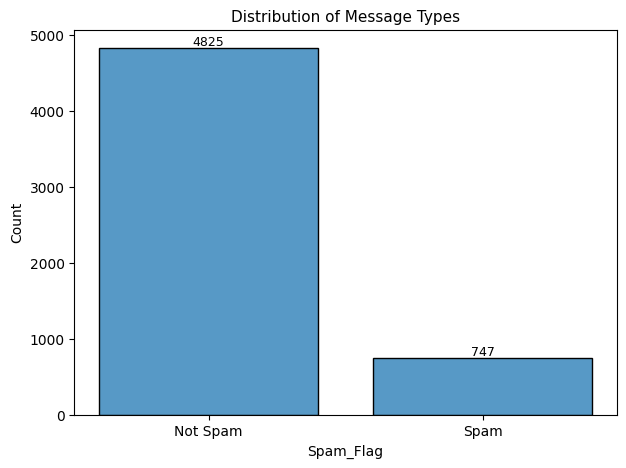

In [15]:
### Check Distro of Spam_Flag
plt.figure(figsize = (7,5))

y= sns.histplot(
    data = Spam_DF_Cleaned,
    x = 'Spam_Flag',
    shrink = 0.8,
)

plt.xticks([0,1],['Not Spam','Spam'])
plt.bar_label(y.containers[0], fontsize = 9)

plt.title("Distribution of Message Types", fontsize = 11)
plt.show()



As expected, not nearly as many spam messages as there is non-spam

In [16]:
### Save Processed DataSet to CSV
Spam_DF_Cleaned.to_csv('GENBUS657_SpamDetection_ProcessedData.csv', index=False)

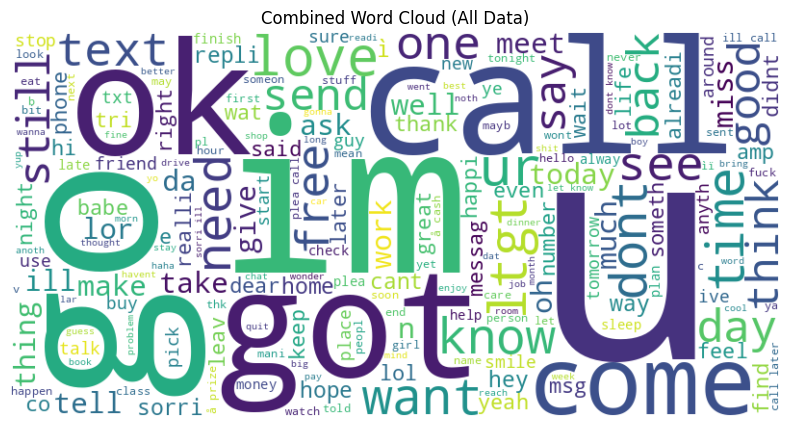

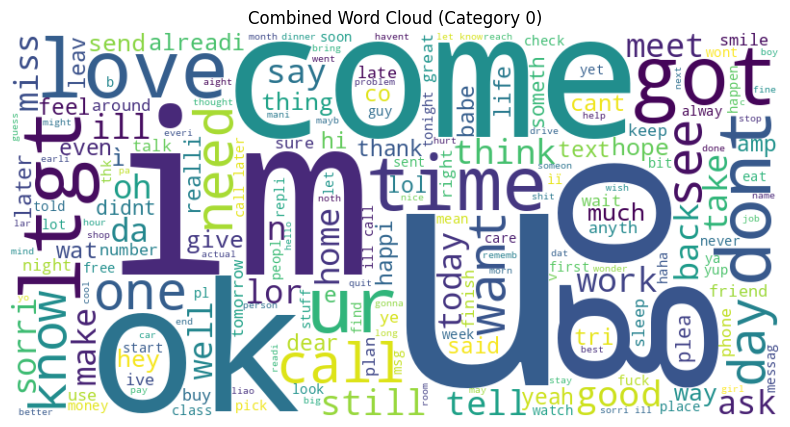

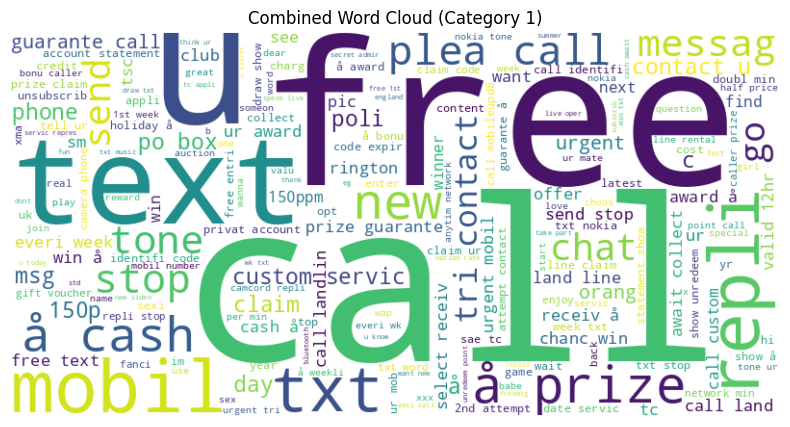

In [17]:
# Function to generate and display word cloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate word cloud for all data
combined_text = ' '.join(Spam_DF_Cleaned['Message'].tolist())
generate_wordcloud(combined_text, "Combined Word Cloud (All Data)")
print()

# Generate word clouds for each category
for category in range(0, 2):
    category_text = ' '.join(Spam_DF_Cleaned[Spam_DF_Cleaned['Spam_Flag'] == category]['Message'].tolist())
    generate_wordcloud(category_text, f"Combined Word Cloud (Category {category})")
    print()

**<u>Notes:</u>**

When visualzing the most common words in each category (Spam vs No Spam) we can clearly see that the Spam Category (1) has words like "Free" or "prize" or "claim". We also see words referencing private numbers or "customer service". This is all consistent with conventional knowledge in terms of typical spam call subject content.

### Modeling

In [18]:
### Text encoding
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(Spam_DF_Cleaned['Message'])
X.shape

(5572, 8016)

In [19]:
### Train Test Split
y = Spam_DF_Cleaned['Spam_Flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) ### 30% in test, 70% in train

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3900, 8016)
(1672, 8016)
(3900,)
(1672,)


#### Logistic Regression:

In [20]:
#### Fit Logisitic Regression on data
model_logistic = LogisticRegression(
    max_iter = 1000,
    class_weight= 'balanced'
    ) ### Accounting for minor class imbalance in target variable (spam vs non-spam)

model_logistic.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

##### Evaluation

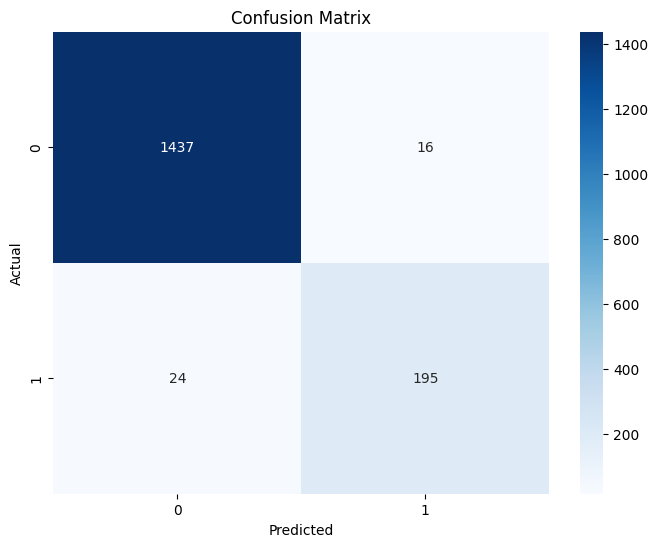

In [21]:
### binary  confusion Matrix
y_pred_log = model_logistic.predict_proba(X_test)[:,1]

### Confusion Matrix
conf_matrix_log = confusion_matrix(y_test,y_pred_log > 0.5)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [22]:
### Evaluation Metrics of model confusion matrix
misclassification_rate_log = (conf_matrix_log[0, 1] + conf_matrix_log[1, 0]) / np.sum(conf_matrix_log)
fp_rate_log = conf_matrix_log[0, 1] / (conf_matrix_log[1, 1] + conf_matrix_log[0, 1])
fn_rate_log = conf_matrix_log[1, 0] / (conf_matrix_log[1, 0] + conf_matrix_log[0, 0])
precision_log = conf_matrix_log[1,1]/(conf_matrix_log[1,1] + conf_matrix_log[0,1])
Accuracy_Log = accuracy_score(y_test,y_pred_log > 0.5)

print(f"Misclassification Rate: {misclassification_rate_log:.4f}")
print(f"False Positive Rate: {fp_rate_log:.4f}")
print(f"False Negative Rate: {fn_rate_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Accuracy: {Accuracy_Log:.4f}")

Misclassification Rate: 0.0239
False Positive Rate: 0.0758
False Negative Rate: 0.0164
Precision: 0.9242
Accuracy: 0.9761


Very strong performance overall. 92% precision with only a 1.6% FN rate and 7.6% false positive rate. The misclassification rate only sits at 2.4%, while accuracy sits at 97.61%.

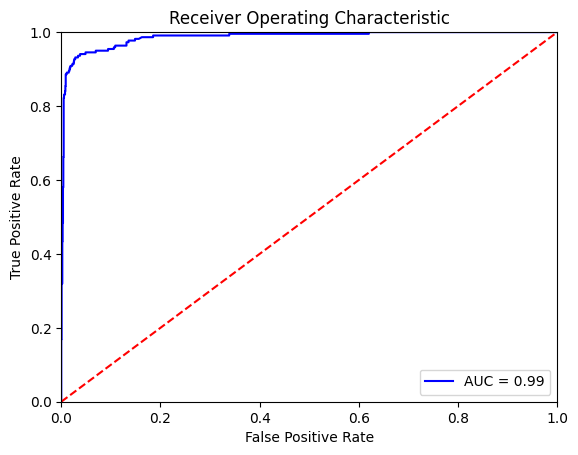

In [23]:
# y_pred_final = Extract(y_pred_final)
fpr_log, tpr_log, threshold_log = roc_curve(y_test, y_pred_log)
roc_auc_final = auc(fpr_log, tpr_log)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr_log, tpr_log, 'b', label = 'AUC = %0.2f' % roc_auc_final)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

ROC Curve for the logistic regression show near perfect separation between the classes by the model (AUC of 0.99). The base logistic Regression does a great job at finding spam emails.

#### Simple Feed Forward Neural Network:

In [24]:
### Levels between 0 and 1
y = Spam_DF_Cleaned['Spam_Flag'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) ### Test size: 30%

In [25]:
# Define the neural network model
model_NN = Sequential()
model_NN.add(Dense(20, activation='relu', input_shape=(X_train.shape[1],))) ### hidden layer (20 neurons)
model_NN.add(Dense(30, activation='relu', input_shape=(X_train.shape[1],))) ### hidden layer (30 neurons)
model_NN.add(Dense(1, activation='sigmoid')) ### Softmax output to account for multiclass classification

# Compile the model
model_NN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) ### choose categ_crossentropy for a classification output

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model_NN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │       160,340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,001 (628.91 KB)

 Trainable params: 161,001 (628.91 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train the model
model_NN.fit(X_train, y_train, epochs=10, batch_size=32, validation_split = 0.2)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8175 - loss: 0.6236 - val_accuracy: 0.8654 - val_loss: 0.3105
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8920 - loss: 0.2318 - val_accuracy: 0.9641 - val_loss: 0.1278
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9858 - loss: 0.0656 - val_accuracy: 0.9769 - val_loss: 0.0881
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9967 - loss: 0.0244 - val_accuracy: 0.9756 - val_loss: 0.0853
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9977 - loss: 0.0110 - val_accuracy: 0.9782 - val_loss: 0.0833
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9996 - loss: 0.0059 - val_accuracy: 0.9769 - val_loss: 0.0863
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9993 - loss: 0.0057 - val_accuracy: 0.9756 - val_loss: 0.0903
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9998 - loss: 0.0030 - val_accuracy: 0.9769 - val_lo

##### Evaluation:

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


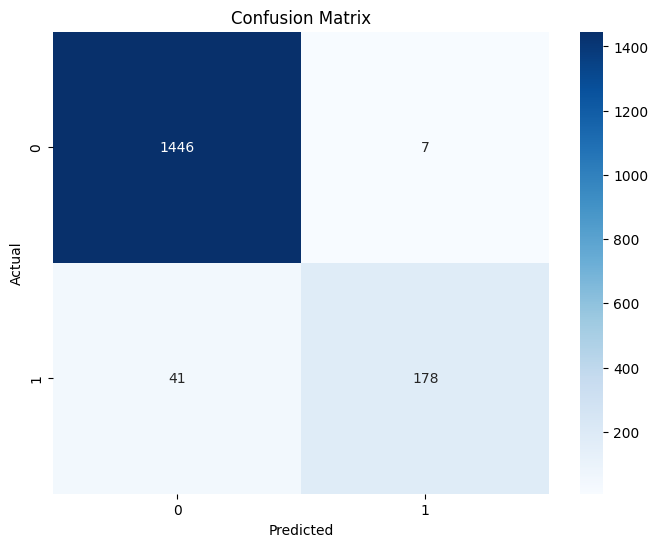

In [28]:
### binary  confusion Matrix
y_pred_NN = model_NN.predict(X_test)
y_pred_classes_NN = (y_pred_NN > 0.5).astype(int).flatten()
y_true_classes_NN = y_test

### Confusion Matrix
conf_matrix_NN = confusion_matrix(y_true_classes_NN,y_pred_classes_NN)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_NN, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [29]:
### Evaluation Metrics of model confusion matrix
misclassification_rate_NN = (conf_matrix_NN[0, 1] + conf_matrix_NN[1, 0]) / np.sum(conf_matrix_NN)
fp_rate_NN = conf_matrix_NN[0, 1] / (conf_matrix_NN[1, 1] + conf_matrix_NN[0, 1])
fn_rate_NN = conf_matrix_NN[1, 0] / (conf_matrix_NN[1, 0] + conf_matrix_NN[0, 0])
precision_NN = conf_matrix_NN[1,1]/(conf_matrix_NN[1,1] + conf_matrix_NN[0,1])
Accuracy_NN = accuracy_score(y_true_classes_NN,y_pred_classes_NN)

print(f"Misclassification Rate: {misclassification_rate_NN:.4f}")
print(f"False Positive Rate: {fp_rate_NN:.4f}")
print(f"False Negative Rate: {fn_rate_NN:.4f}")
print(f"Precision: {precision_NN:.4f}")
print(f"Accuracy: {Accuracy_NN:.4f}")

Misclassification Rate: 0.0287
False Positive Rate: 0.0378
False Negative Rate: 0.0276
Precision: 0.9622
Accuracy: 0.9713


The simple Neural Net Design (2 hidden layers) did quite well, beating the logistic regression in terms of precision (0.9779 vs 0.9242). Accuracy Performance was relatively the same. In this case, the NN was not really necessary, but we will try a more complex design to see if there is any improvement.

#### LSTM Model:

Perform different pre-processing technique

##### Pre-processing:

In [30]:
### Create New Copy of Spam_DF
Spam_DF_Cleaned2 = Spam_DF.copy()
### Remove uneeded columns from copy
Spam_DF_Cleaned2 = Spam_DF_Cleaned2.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'])
### Rename Columns
Spam_DF_Cleaned2 = Spam_DF_Cleaned2.rename(
    columns = {
        'v1' : 'Spam_Flag',
        'v2' : 'Message'
    }
  )
### Re-Classify Spam_Flag Field
Spam_DF_Cleaned2['Spam_Flag'] = np.where(Spam_DF_Cleaned2['Spam_Flag'] == 'ham','not spam','spam')

### Convert Spam_Flag Field to Dummy Variable
Spam_DF_Cleaned2['Spam_Flag'] = np.where(Spam_DF_Cleaned2['Spam_Flag'] == 'spam', 1, 0)

### Convert Spam_Flag Field to Categorical Variable
# Spam_DF_Cleaned2['Spam_Flag'] = pd.Categorical(Spam_DF_Cleaned2['Spam_Flag'])

In [31]:
### View DF
Spam_DF_Cleaned2.head()

,Spam_Flag,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [32]:
### Set Target and Feature Vector
X_LSTM = Spam_DF_Cleaned2['Message']
Y_LSTM = Spam_DF_Cleaned2['Spam_Flag']

Apply Tokenization Technique:

In [33]:
vocab_size = 10000 # arbitrarily chosen
embed_size = 32 # arbitrarily chosen

# Create and Fit tokenizer
tok = Tokenizer(num_words=vocab_size)
tok.fit_on_texts(X_LSTM.values)

In [ ]:
### Check the indexes of each token
tok.word_index

In [35]:
### Convert Sequences to Numbers
X_LSTM_Values = tok.texts_to_sequences(X_LSTM)

In [36]:
### Confirm that feature vector is 5572 records
len(X_LSTM_Values)

5572

In [ ]:
### View First Element
X_LSTM_Values[1084]

In [38]:
### Check the sequence with the most elements
max_len = 0
max_len_index = 0

for i,seq in enumerate(X_LSTM_Values):
  if len(seq) > max_len:
    max_len = len(seq)
    max_len_index = i

print(f"The vector with the most elements is at index {max_len_index} with {max_len} elements.")

The vector with the most elements is at index 1084 with 189 elements.


In [39]:
### Padding
X_LSTM_Values = pad_sequences(X_LSTM_Values, maxlen = max_len)

##### Modeling:

In [40]:
### Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X_LSTM_Values, Y_LSTM, test_size=0.3, random_state=42) ### Test size: 30%

In [55]:
### More Complex LSTM Fit
model_LSTM = Sequential() ### Sequential Model
model_LSTM.add(Embedding(input_dim = vocab_size, output_dim=embed_size,input_length=max_len,input_shape=(max_len,))) ### Sequences of 189 items (feature vectors) each x is a 32x32 dimentional vector that represents the word in the embedding space.
model_LSTM.add(LSTM(128, return_sequences=True)) ### 128 neurons (hidden states)
#model.add(Bidirectional(LSTM(128, return_sequences=True))) # for bi-directional
model_LSTM.add(LSTM(64, return_sequences=True)) ### another LSTM layer with 64 neurons
model_LSTM.add(GlobalMaxPooling1D()) #Looking at the maximum element (dimensionality reduction method)
model_LSTM.add(Dense(64)) ### Dense layer with 64 neurons (general neural network lay er)
model_LSTM.add(Dropout(0.25)) ### helps with overfitting (aribtralily sets things to 0)
model_LSTM.add(Dense(32)) ### dense layer with 32 neurons
model_LSTM.add(Dropout(0.25))
model_LSTM.add(Dense(1, activation='sigmoid')) ### Use for binary classification
model_LSTM.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 189, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 189, 128)       │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 189, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,113 (1.75 MB)

 Trainable params: 458,113 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
### Complile Model
model_LSTM.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [57]:
### Fit Model
model_LSTM.fit(X_train,
          y_train.astype(int),
          batch_size=256,
          validation_data=(X_test, y_test),
          epochs=12)

Epoch 1/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8560 - loss: 0.5396 - val_accuracy: 0.8690 - val_loss: 0.3868
Epoch 2/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8666 - loss: 0.3969 - val_accuracy: 0.8690 - val_loss: 0.3548
Epoch 3/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8625 - loss: 0.3398 - val_accuracy: 0.8684 - val_loss: 0.2503
Epoch 4/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9289 - loss: 0.1946 - val_accuracy: 0.9731 - val_loss: 0.0942
Epoch 5/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9831 - loss: 0.0657 - val_accuracy: 0.9779 - val_loss: 0.0837
Epoch 6/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9880 - loss: 0.0355 - val_accuracy: 0.9850 - val_loss: 0.0707
Epoch 7/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9957 - loss: 0.0191 - val_accuracy: 0.9839 - val_loss: 0.0676
Epoch 8/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9968 - loss: 0.0131 - val_accuracy: 0.9839 - val_loss:

53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step


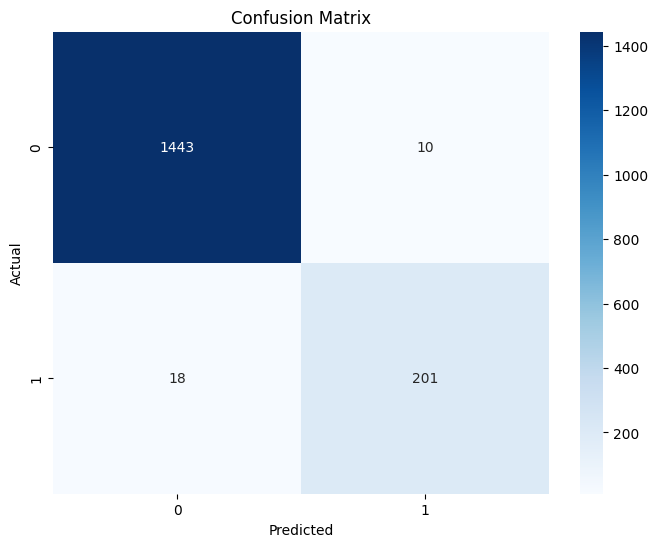

In [58]:
### binary  confusion Matrix
y_pred_LSTM = model_LSTM.predict(X_test)
y_pred_classes_LSTM  = (y_pred_LSTM > 0.5).astype(int).flatten()
y_true_classes_LSTM  = y_test

### Confusion Matrix
conf_matrix_LSTM = confusion_matrix(y_true_classes_LSTM,y_pred_classes_LSTM)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_LSTM, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [59]:
### Evaluation Metrics of model confusion matrix
misclassification_rate_LSTM = (conf_matrix_LSTM[0, 1] + conf_matrix_LSTM[1, 0]) / np.sum(conf_matrix_LSTM)
fp_rate_LSTM  = conf_matrix_LSTM[0, 1] / (conf_matrix_LSTM[1, 1] + conf_matrix_LSTM[0, 1])
fn_rate_LSTM  = conf_matrix_LSTM[1, 0] / (conf_matrix_LSTM[1, 0] + conf_matrix_LSTM[0, 0])
precision_LSTM  = conf_matrix_LSTM[1,1]/(conf_matrix_LSTM[1,1] + conf_matrix_LSTM[0,1])
Accuracy_LSTM  = accuracy_score(y_true_classes_LSTM,y_pred_classes_LSTM)

print(f"Misclassification Rate: {misclassification_rate_LSTM:.4f}")
print(f"False Positive Rate: {fp_rate_LSTM:.4f}")
print(f"False Negative Rate: {fn_rate_LSTM:.4f}")
print(f"Precision: {precision_LSTM:.4f}")
print(f"Accuracy: {Accuracy_LSTM:.4f}")

Misclassification Rate: 0.0167
False Positive Rate: 0.0474
False Negative Rate: 0.0123
Precision: 0.9526
Accuracy: 0.9833


53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step


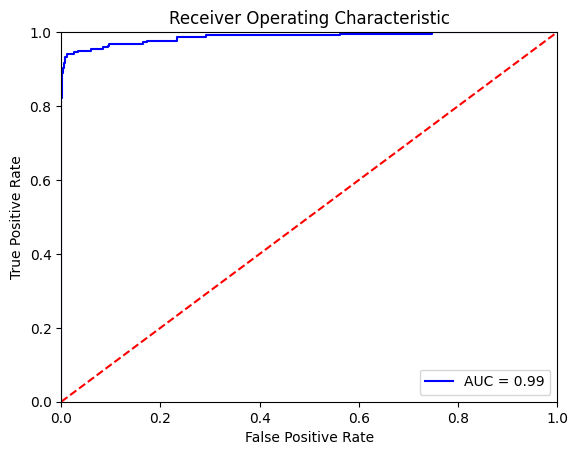

In [60]:
### ROC Curve
y_pred_LSTM = model_LSTM.predict(X_test).ravel()   # <- flatten to 1D

fpr_LSTM, tpr_LSTM, thresholds_LSTM = roc_curve(y_test.astype(int), y_pred_LSTM)
roc_auc_LSTM = auc(fpr_LSTM, tpr_LSTM)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr_LSTM, tpr_LSTM, 'b', label = 'AUC = %0.2f' % roc_auc_LSTM)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

The LSTM Neural Net provided the best performance/fit on the data across the board. It has the best accuracy and precision of all 3 models tested while having only a 1.56% misclassification rate. We also see that the AUC is the same as the Logistic Regression Model.

### **<u>Final Notes:</u>**

The LSTM model was the winner here in terms of overall performance. It's overall ability to accuractly distinguish between the classes, and yield high precision and accuracy makes it fine choice for this specific application of trying to predict which email messages are "Spam".

It should be noted, however, that the basic logistic model (with only class balancing added and no additional tuning) performed fairly well in its own right, owning an AUC of 0.99 along with a  Precision of 0.9242 and Accuracy of 0.9761. With more tuning, the logistic model could potentially approach the level of the neural net model in terms of predicting power while saving on overall computational performance.